# Change-Point Detection in Time-Series Data

Change-point detection is a technique used to identify points in a time series where the underlying probability distribution or data-generating process changes.

### Key Applications
* **Finance:** Detecting shifts in market volatility or stock trends.
* **IoT & Monitoring:** Identifying anomalies or hardware failures in sensor streams.
* **Epidemiology:** Tracking sudden shifts in disease transmission rates.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt  # Install using: pip install ruptures

# 1. Generate synthetic time-series data with mean shifts
np.random.seed(42)
n_samples = 300
signal_1 = np.random.normal(loc=10, scale=1.5, size=100)
signal_2 = np.random.normal(loc=25, scale=2.0, size=100)
signal_3 = np.random.normal(loc=5, scale=1.0, size=100)

data = np.concatenate([signal_1, signal_2, signal_3])

# 2. Perform Change-Point Detection using Pruned Exact Linear Time (PELT)
algo = rpt.Pelt(model="rbf").fit(data)
result = algo.predict(pen=10)

print(f"Detected Change Points at Indices: {result}")

Detected Change Points at Indices: [100, 200, 300]


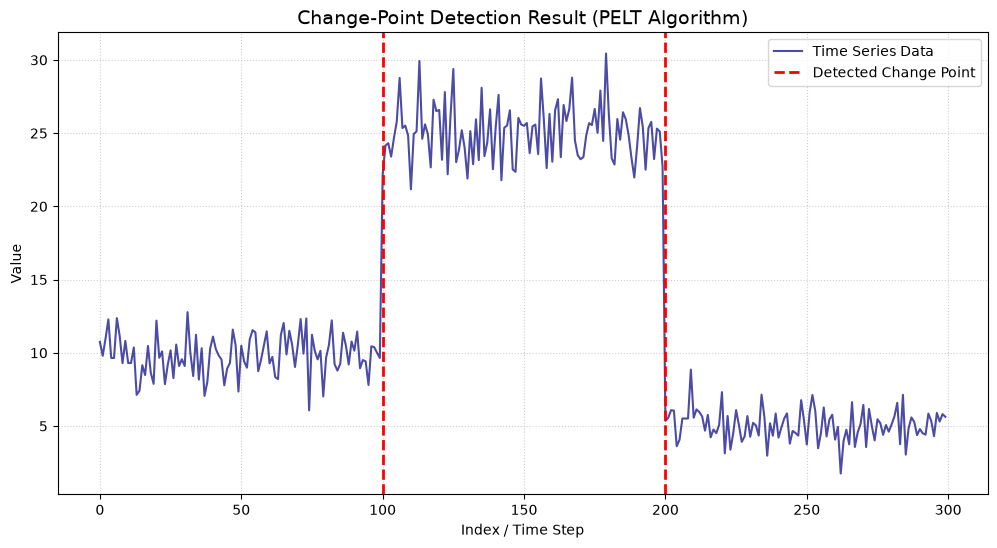

In [3]:
# 3. Visualization
plt.figure(figsize=(12, 6))
plt.plot(data, label="Time Series Data", color="navy", alpha=0.7)

# Draw change point markers
for cp in result[:-1]:  # Exclude final boundary index
    plt.axvline(x=cp, color="red", linestyle="--", linewidth=2, label="Detected Change Point")

# Deduplicate legend labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title("Change-Point Detection Result (PELT Algorithm)", fontsize=14)
plt.xlabel("Index / Time Step")
plt.ylabel("Value")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

## Common Algorithms

| Algorithm | Type | Description |
| :--- | :--- | :--- |
| **PELT** | Offline | Exact search method; efficient for unknown number of change points |
| **Binary Segmentation** | Offline | Fast greedy approach; recursively splits time series |
| **CUMSUM** | Online/Offline | Sequential analysis method monitoring cumulative sums of deviations |
| **BOCPD** | Online | Bayesian approach updating posterior probabilities sequentially |

# Pruned Exact Linear Time (PELT) Algorithm

The **PELT** algorithm is an exact, offline change-point detection method that finds optimal segmentations in time-series data in linear computational time.

---

### Key Characteristics
* **Exactness:** Guarantees finding the global minimum of the penalized cost function without using greedy approximations.
* **Linear Time Complexity ($O(n)$):** Reduces search space drastically using inequality-based pruning.
* **Offline Processing:** Requires the complete time-series dataset to compute change points.

---

### Mathematical Formulation

PELT minimizes the total cost across $k$ change points $\tau = (\tau_1, \tau_2, \dots, \tau_k)$:

$$\min_{\tau} \sum_{i=1}^{k+1} \left[ \mathcal{C}(y_{(\tau_{i-1}+1):\tau_i}) \right] + \beta f(k)$$

Where:
* $\mathcal{C}(\cdot)$ is the cost function (e.g., L2 norm for mean shifts, radial basis function).
* $\beta > 0$ is the penalty parameter controlling model complexity to prevent over-fitting.
* $f(k)$ is the penalty function, usually $f(k) = k$.

---

### Comparison of Common Algorithms

| Algorithm | Type | Time Complexity | Best Use Case |
| :--- | :--- | :--- | :--- |
| **PELT** | Offline | $O(n)$ | Exact search for unknown number of change points |
| **Binary Segmentation** | Offline | $O(n \log n)$ | Fast approximate search |
| **CUMSUM** | Online/Offline | $O(n)$ | Detecting mean shifts sequentially |
| **BOCPD** | Online | $O(n)$ | Real-time Bayesian probability updates |

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt  # Install via: pip install ruptures

# 1. Generate synthetic signal with shift in mean
np.random.seed(42)
n_samples = 300
segment_1 = np.random.normal(loc=10, scale=1.2, size=100)
segment_2 = np.random.normal(loc=22, scale=1.8, size=100)
segment_3 = np.random.normal(loc=5, scale=1.0, size=100)

data = np.concatenate([segment_1, segment_2, segment_3])

# 2. Run PELT algorithm using L2 cost model
algo = rpt.Pelt(model="l2").fit(data)
change_points = algo.predict(pen=10)

print(f"Detected change points at indices: {change_points[:-1]}")

Detected change points at indices: [100, 200]


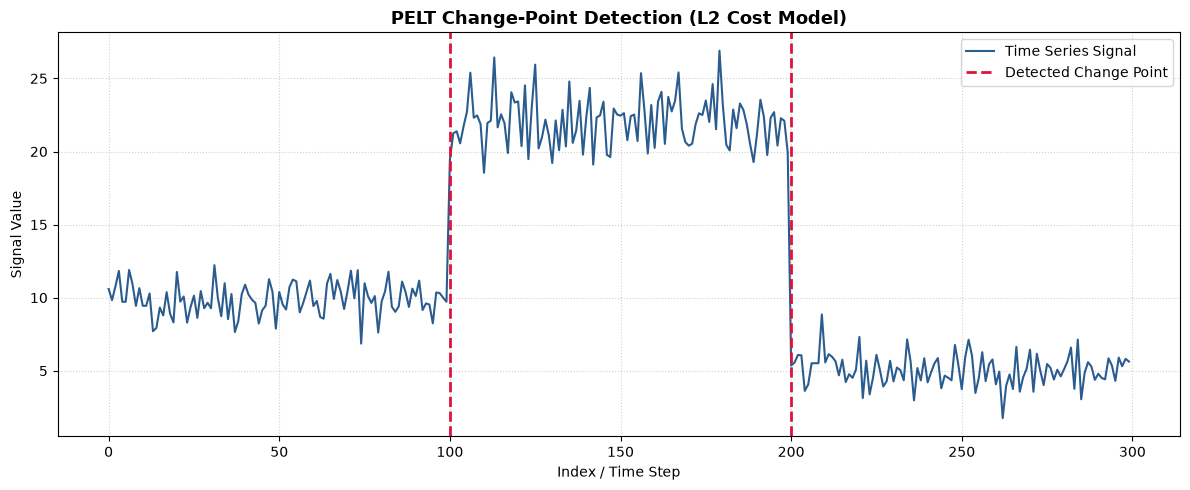

In [6]:
# 3. Visualization
plt.figure(figsize=(12, 5))
plt.plot(data, label="Time Series Signal", color="#2b5c8f", lw=1.5)

# Plot detected change points
for cp in change_points[:-1]:
    plt.axvline(x=cp, color="crimson", linestyle="--", linewidth=2, label="Detected Change Point")

# Deduplicate legend labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="upper right")

plt.title("PELT Change-Point Detection (L2 Cost Model)", fontsize=13, fontweight="bold")
plt.xlabel("Index / Time Step")
plt.ylabel("Signal Value")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# Binary Segmentation Algorithm

**Binary Segmentation (BinSeg)** is one of the most widely used approximate, greedy methods for offline change-point detection in time-series data.

---

### Key Characteristics
* **Greedy & Recursive:** Begins by finding the single most significant change point in the full dataset, splits the series into two sub-segments at that point, and recursively repeats the process on each sub-segment.
* **Speed:** Highly efficient with a computational complexity of $O(n \log n)$ when stopping conditions or maximum change-point counts are applied.
* **Approximate Solution:** Unlike PELT, Binary Segmentation does not guarantee finding the global minimum cost, as early sub-optimal splits cannot be undone in later steps.

---

### Mathematical Formulation

At each recursive step over a segment $y_{1:N}$, the algorithm searches for a single change point $k$ that minimizes the sum of costs of the two resulting sub-segments:

$$\hat{k} = \arg\min_{1 \le k < N} \left[ \mathcal{C}(y_{1:k}) + \mathcal{C}(y_{(k+1):N}) \right]$$

The process continues recursively on sub-segments until one of the stopping criteria is met:
1. The decrease in total cost falls below a defined penalty/threshold $\beta$.
2. The predefined maximum number of change points $n_{\text{bkps}}$ is reached.

---

### Advantages vs. Limitations

* **Advantages:**
  * Simple conceptual framework and easy implementation.
  * Extremely fast execution on large datasets ($O(n \log n)$).
  * Works well when change points are well-separated and distinct.

* **Limitations:**
  * Can fail to detect change points that only become apparent when considering multiple points simultaneously (e.g., short spikes or transient shifts).
  * Sub-optimal local choices early in the process propagate through remaining steps.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt  # Install via: pip install ruptures

# 1. Generate synthetic signal with mean shifts
np.random.seed(42)
segment_1 = np.random.normal(loc=12, scale=1.0, size=100)
segment_2 = np.random.normal(loc=30, scale=2.0, size=100)
segment_3 = np.random.normal(loc=8, scale=1.2, size=100)

data = np.concatenate([segment_1, segment_2, segment_3])

# 2. Run Binary Segmentation algorithm predicting up to 2 change points
algo = rpt.Binseg(model="l2").fit(data)
change_points = algo.predict(n_bkps=2)

print(f"Detected change points at indices: {change_points[:-1]}")

Detected change points at indices: [100, 200]


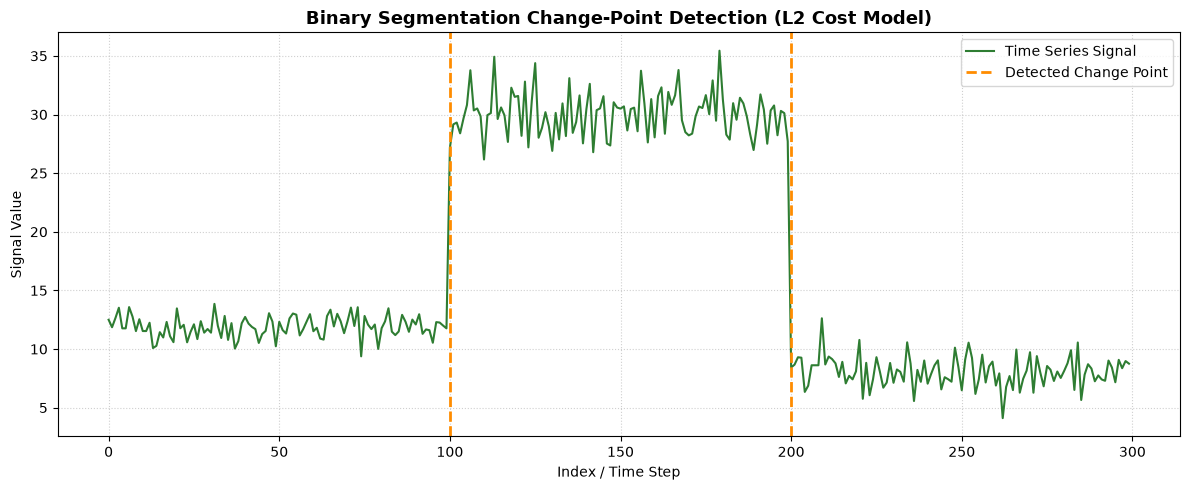

In [8]:
# 3. Visualization
plt.figure(figsize=(12, 5))
plt.plot(data, label="Time Series Signal", color="#2e7d32", lw=1.5)

# Plot detected change points
for cp in change_points[:-1]:
    plt.axvline(x=cp, color="darkorange", linestyle="--", linewidth=2, label="Detected Change Point")

# Deduplicate legend labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="upper right")

plt.title("Binary Segmentation Change-Point Detection (L2 Cost Model)", fontsize=13, fontweight="bold")
plt.xlabel("Index / Time Step")
plt.ylabel("Signal Value")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# CUMSUM (Cumulative Sum) Algorithm

**CUMSUM** is a sequential statistical process control algorithm used to detect subtle shifts in the mean of a process or time-series signal over time.

---

### Key Characteristics
* **Online & Offline Detection:** Originally designed for real-time (online) monitoring of streaming data, but also suitable for post-hoc (offline) analysis.
* **Sensitivity to Small Shifts:** Monitors the cumulative sum of deviations from a target baseline, making it much more effective at detecting small, sustained mean shifts than standard control charts.
* **Low Computational Cost:** Memory-efficient with $O(1)$ updates per time step, making it ideal for edge devices and real-time monitoring system alerts.

---

### Mathematical Formulation

Given a sequence of observations $x_1, x_2, \dots, x_t$ with expected baseline mean $\mu_0$ and allowable drift parameter $k$:

1. **Upper Cumulative Sum (Detects upward shifts):**
   $$S_t^+ = \max\left(0, S_{t-1}^+ + (x_t - \mu_0 - k)\right)$$

2. **Lower Cumulative Sum (Detects downward shifts):**
   $$S_t^- = \max\left(0, S_{t-1}^- + (\mu_0 - x_t - k)\right)$$

Where:
* $S_0^+ = S_0^- = 0$.
* $k$ is the drift parameter (typically set to half the expected shift size $\delta / 2$).
* An alarm/change point is flagged as soon as either $S_t^+ > h$ or $S_t^- > h$, where $h$ is the decision threshold.

---

### Advantages vs. Limitations

* **Advantages:**
  * Highly sensitive to small and step-wise mean shifts.
  * Simple and fast to implement in streaming data pipelines.
  * Provides low detection latency.

* **Limitations:**
  * Requires explicit specification or estimation of the baseline mean $\mu_0$ and variance $\sigma$.
  * Sensitive to noise and false alarms if threshold $h$ and allowance $k$ are poorly tuned.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate synthetic signal with mean shift
np.random.seed(42)
segment_1 = np.random.normal(loc=10.0, scale=1.0, size=100)
segment_2 = np.random.normal(loc=12.5, scale=1.0, size=100)  # Sustained shift in mean
data = np.concatenate([segment_1, segment_2])

# 2. Define CUMSUM algorithm parameters
target_mean = 10.0  # Known or baseline mean
drift = 0.5         # Allowance parameter k
threshold = 8.0     # Decision threshold h

# 3. Compute CUMSUM statistic
s_plus = np.zeros(len(data))
s_minus = np.zeros(len(data))
change_points = []

for t in range(1, len(data)):
    s_plus[t] = max(0, s_plus[t - 1] + (data[t] - target_mean - drift))
    s_minus[t] = max(0, s_minus[t - 1] + (target_mean - data[t] - drift))
    
    # Check if threshold is breached
    if s_plus[t] > threshold or s_minus[t] > threshold:
        change_points.append(t)

print(f"First threshold breach detected at index: {change_points[0] if change_points else 'None'}")

First threshold breach detected at index: 105


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/5q/3bzc5mns2p1cmjf0x0b446br0000gn/T/ipykernel_54364/2203053394.py:6: SyntaxWarning: invalid escape sequence '\m'
  ax1.axhline(y=target_mean, color="black", linestyle=":", label="Baseline Mean ($\mu_0$)")


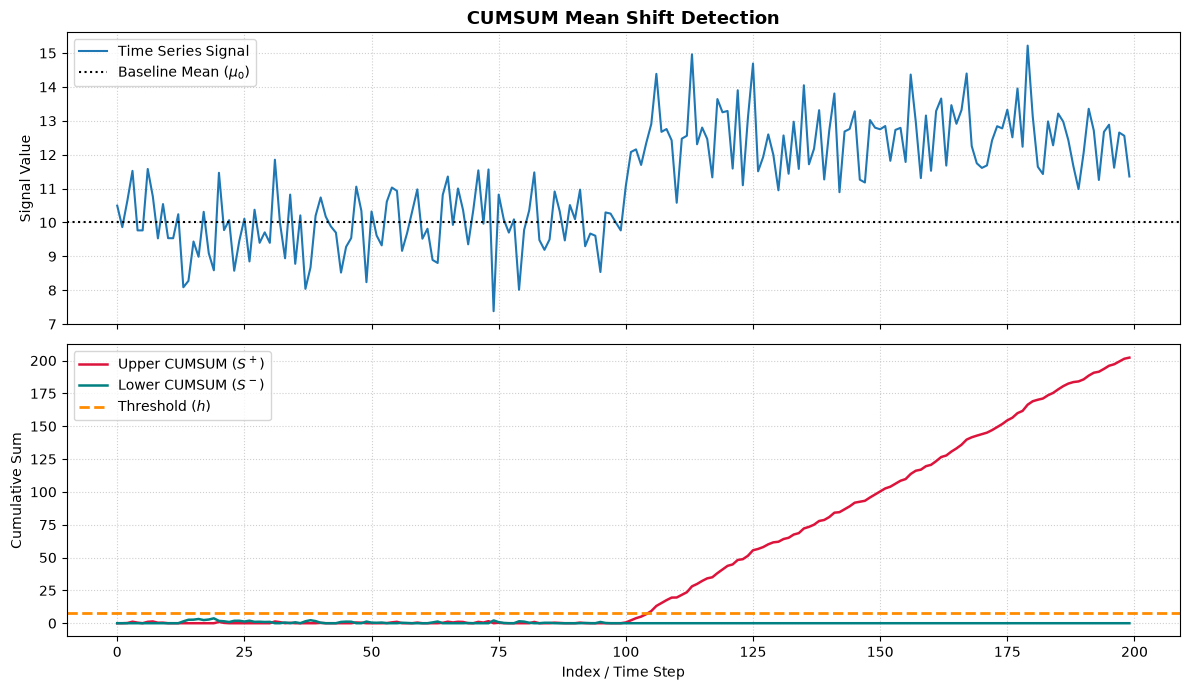

In [10]:
# 4. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Plot raw signal
ax1.plot(data, label="Time Series Signal", color="#1f77b4", lw=1.5)
ax1.axhline(y=target_mean, color="black", linestyle=":", label="Baseline Mean ($\mu_0$)")
ax1.set_title("CUMSUM Mean Shift Detection", fontsize=13, fontweight="bold")
ax1.set_ylabel("Signal Value")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper left")

# Plot CUMSUM statistics
ax2.plot(s_plus, label="Upper CUMSUM ($S^+$)", color="crimson", lw=1.8)
ax2.plot(s_minus, label="Lower CUMSUM ($S^-$)", color="teal", lw=1.8)
ax2.axhline(y=threshold, color="darkorange", linestyle="--", lw=2, label="Threshold ($h$)")
ax2.set_ylabel("Cumulative Sum")
ax2.set_xlabel("Index / Time Step")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

# Bayesian Online Change-Point Detection (BOCPD)

**Bayesian Online Change-Point Detection (BOCPD)** is a probabilistic algorithm designed to process time-series data sequentially (online) and estimate the probability distribution of the **run length** (the time elapsed since the last change point).

---

### Key Characteristics
* **Online Processing:** Processes observations one step at a time as new data arrives ($O(1)$ per time step).
* **Probabilistic Output:** Outputs a full posterior distribution over the run length $r_t$ rather than just a deterministic split index.
* **Predictive Distribution:** Incorporates a underlying predictive model (UPM) to evaluate how well incoming data fits existing parameters versus starting a new regime.

---

### Mathematical Formulation

Let $r_t$ denote the run length at time step $t$. At each step, the run length either increments by 1 (no change point) or resets to 0 (a change point occurred):

$$P(r_t \mid x_{1:t}) \propto \sum_{r_{t-1}} P(r_t \mid r_{t-1}) \cdot P(x_t \mid r_{t-1}, x_{1:t-1}) \cdot P(r_{t-1} \mid x_{1:t-1})$$

Where:
* **Hazard Function $P(r_t \mid r_{t-1})$:** Models the prior probability of a change point occurring. A constant hazard rate is defined as $H(r) = 1 / \lambda$, where $\lambda$ is the expected time between change points.
* **Underlying Predictive Model $P(x_t \mid r_{t-1}, x_{1:t-1})$:** The marginal likelihood of observing $x_t$ given data from the current run length.

---

### Advantages vs. Limitations

* **Advantages:**
  * Ideal for real-time monitoring, streaming data, and immediate anomaly alerts.
  * Quantifies uncertainty in change-point timing via posterior probabilities.
  * Adapts quickly to new data distributions after a shift.

* **Limitations:**
  * Computational cost scales linearly with $t$ without message pruning.
  * Hyperparameters (such as hazard rate $\lambda$ and prior belief distributions) must be specified accurately.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Generate synthetic signal with mean shifts
np.random.seed(42)
segment_1 = np.random.normal(loc=5.0, scale=1.0, size=100)
segment_2 = np.random.normal(loc=15.0, scale=1.0, size=100)
segment_3 = np.random.normal(loc=8.0, scale=1.0, size=100)

data = np.concatenate([segment_1, segment_2, segment_3])
T = len(data)

# 2. Setup BOCPD parameters
lambda_hazard = 100  # Expected time steps between change points
H = 1.0 / lambda_hazard

# Online Bayesian priors (Gaussian with known variance)
var_x = 1.0          # Data variance
var_0 = 10.0         # Initial mean variance
mu_0 = 0.0           # Initial mean estimate

# Initialize Run-Length Posterior Matrix
R = np.zeros((T + 1, T + 1))
R[0, 0] = 1.0

# Sufficient statistics for Gaussian model
mu_params = np.zeros((T + 1, T + 1))
var_params = np.zeros((T + 1, T + 1))
mu_params[0, 0] = mu_0
var_params[0, 0] = var_0

# 3. Online updates
for t in range(1, T + 1):
    x = data[t - 1]
    
    # Evaluate predictive probabilities for all possible run lengths
    pred_means = mu_params[:t, t - 1]
    pred_vars = var_params[:t, t - 1] + var_x
    pred_probs = norm.pdf(x, loc=pred_means, scale=np.sqrt(pred_vars))
    
    # Calculate growth probabilities and reset probability
    growth_probs = R[:t, t - 1] * pred_probs * (1 - H)
    cp_prob = np.sum(R[:t, t - 1] * pred_probs * H)
    
    # Update Run Length distribution
    R[0, t] = cp_prob
    R[1:t + 1, t] = growth_probs
    
    # Normalize distribution
    R[:, t] /= np.sum(R[:, t])
    
    # Update Bayesian conjugate prior parameters for step t
    new_var = 1.0 / (1.0 / var_params[:t, t - 1] + 1.0 / var_x)
    new_mu = new_var * (mu_params[:t, t - 1] / var_params[:t, t - 1] + x / var_x)
    
    mu_params[0, t] = mu_0
    var_params[0, t] = var_0
    mu_params[1:t + 1, t] = new_mu
    var_params[1:t + 1, t] = new_var

print("BOCPD computation completed successfully.")

BOCPD computation completed successfully.


<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/var/folders/5q/3bzc5mns2p1cmjf0x0b446br0000gn/T/ipykernel_54364/1720967344.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_title("Run Length Posterior Probability $P(r_t \mid x_{1:t})$", fontsize=11)


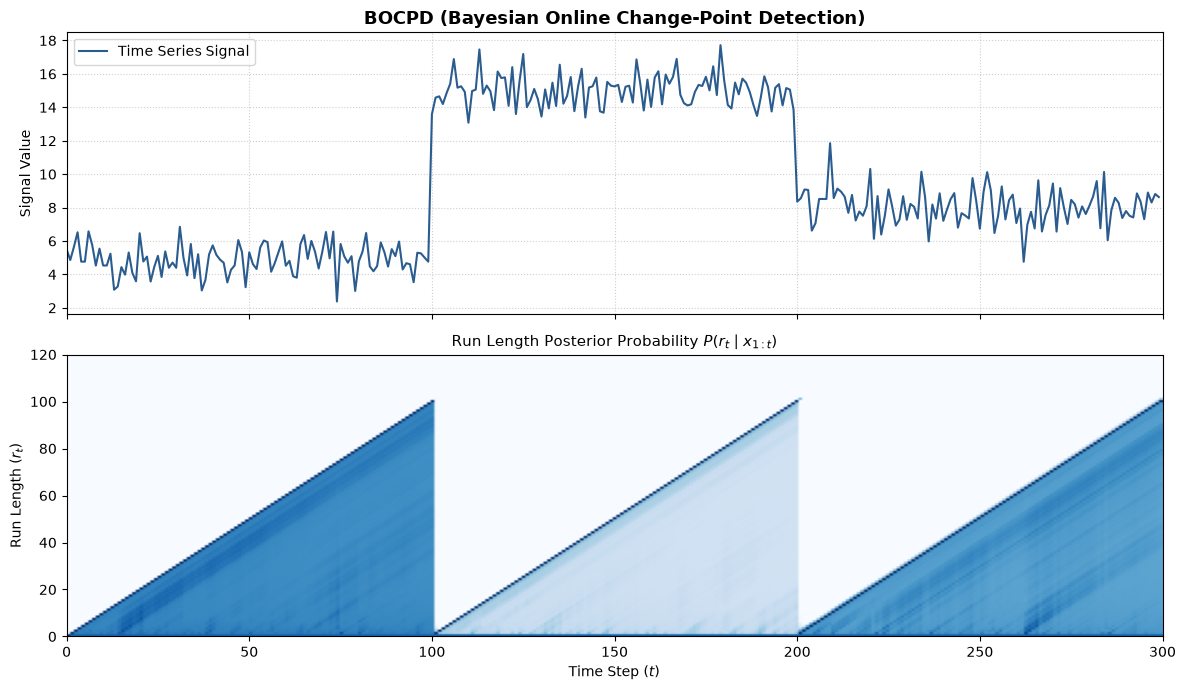

In [12]:
# 4. Plot original data alongside the run-length probability heatmap
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Plot raw signal
ax1.plot(data, color="#2b5c8f", lw=1.5, label="Time Series Signal")
ax1.set_title("BOCPD (Bayesian Online Change-Point Detection)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Signal Value")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper left")

# Plot run-length posterior heatmap
ax2.imshow(
    np.log(R + 1e-10),
    aspect="auto",
    cmap="Blues",
    origin="lower",
    extent=[0, T, 0, T]
)
ax2.set_title("Run Length Posterior Probability $P(r_t \mid x_{1:t})$", fontsize=11)
ax2.set_xlabel("Time Step ($t$)")
ax2.set_ylabel("Run Length ($r_t$)")
ax2.set_ylim(0, 120)

plt.tight_layout()
plt.show()

# Bayesian Change-Point Detection (PyMC3)

**Bayesian Change-Point Detection** uses probabilistic programming to model time-series data and infer when a structural shift occurred by estimating posterior probability distributions rather than single point estimates.

---

### Key Characteristics
* **Probabilistic Output:** Rather than returning a single deterministic index, it provides a full posterior distribution for the change point ($\tau$) and parameters before/after the shift [00:11:23].
* **Handles Missing Data:** Automatically models missing observations seamlessly through probabilistic priors without manual imputation [00:01:37, 00:07:31].
* **Hybrid Samplers:** Uses NUTS (No-U-Turn Sampler) for continuous variables and Metropolis-Hastings for discrete parameters (like the integer change-point year) [00:08:16, 00:08:25].

---

### Mathematical Model Formulation

For a count time series $y_t$ (e.g., annual coal mining disasters from 1851 to 1962):

1. **Likelihood Model:**
   $$y_t \sim \text{Poisson}(\mu_t)$$

2. **Rate Parameter with Switch Point ($\tau$):**
   $$\mu_t = \begin{cases} e_1 & \text{if } t < \tau \\ e_2 & \text{if } t \ge \tau \end{cases}$$

3. **Priors:**
   * Early rate parameter: $e_1 \sim \text{Exponential}(\lambda)$
   * Late rate parameter: $e_2 \sim \text{Exponential}(\lambda)$
   * Switch point index: $\tau \sim \text{DiscreteUniform}(t_{\text{start}}, t_{\text{end}})$ [00:06:08]

---

### Advantages vs. Limitations

* **Advantages:**
  * Quantifies uncertainty surrounding when the shift occurred [00:11:16].
  * Highly customizable to different distributions (Poisson, Normal, Exponential) [00:03:32, 00:06:30].
  * Naturally handles missing values without dropping records [00:07:31].

* **Limitations:**
  * Computationally intensive due to Markov Chain Monte Carlo (MCMC) sampling [00:08:42].
  * Requires explicit prior distributions for model parameters [00:05:33].

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pymc3 as pm  # Install via: pip install pymc3
import theano.tensor as tt

# 1. Generate synthetic count data simulating a Poisson process with a shift
np.random.seed(42)
years = np.arange(1851, 1963)
n_years = len(years)

# True rate shift around year 1890 (index 39)
true_e1, true_e2 = 3.5, 1.1
data = np.concatenate([
    np.random.poisson(true_e1, size=39),
    np.random.poisson(true_e2, size=n_years - 39)
]).astype(float)

# Introduce missing values (simulating real-world datasets)
data[10], data[11] = np.nan, np.nan
masked_data = np.ma.masked_invalid(data)

# 2. Define and run the PyMC3 Bayesian model
with pm.Model() as disaster_model:
    # Priors for early/late rates and discrete switch point
    switchpoint = pm.DiscreteUniform("switchpoint", lower=0, upper=n_years - 1)
    early_rate = pm.Exponential("early_rate", 1.0)
    late_rate = pm.Exponential("late_rate", 1.0)

    # Deterministic rate parameter selection using Theano switch
    idx = np.arange(n_years)
    rate = pm.math.switch(switchpoint >= idx, early_rate, late_rate)

    # Likelihood function
    disasters = pm.Poisson("disasters", mu=rate, observed=masked_data)

    # Perform MCMC sampling (automates NUTS and Metropolis samplers)
    trace = pm.sample(draws=2000, tune=1000, return_inferencedata=False, random_seed=42)

print("Sampling complete.")

ModuleNotFoundError: No module named 'pymc3'

In [15]:
# 3. Visualization
plt.figure(figsize=(12, 6))

# Plot raw observations
plt.plot(years, data, "o-", color="#2b5c8f", alpha=0.7, label="Observed Disasters")

# Calculate estimated switch point mean and year
est_tau_idx = int(np.mean(trace["switchpoint"]))
est_year = years[est_tau_idx]

# Plot estimated change point from posterior distribution
plt.axvline(x=est_year, color="crimson", linestyle="--", linewidth=2, 
            label=f"Estimated Switch Point (~{est_year})")

plt.title("Bayesian Change-Point Detection (PyMC3 Poisson Model)", fontsize=13, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Disaster Count")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# 4. Display posterior summary plot
pm.plot_posterior(trace, var_names=["early_rate", "late_rate", "switchpoint"], figsize=(12, 4))
plt.tight_layout()
plt.show()

NameError: name 'years' is not defined

<Figure size 1200x600 with 0 Axes>

# Time Series Forecasting: FFT & Sequence-to-Sequence (Deep Learning)

This notebook covers two scalable and practical approaches for time-series forecasting: **Fast Fourier Transform (FFT) Decomposition** for periodic signals and **Sequence-to-Sequence (Seq2Seq)** architectures for complex multi-variable signals.

---

### Algorithm 1: Fast Fourier Transform (FFT) Decomposition

FFT decomposes periodic time-series data into a summation of simple sine waves, each defined by an amplitude, frequency, and phase [00:01:22, 00:01:46].

* **Key Characteristics:**
  * **Decomposition:** Converts complex time domain signals into the frequency domain [00:01:08].
  * **Filtering & Smoothing:** Removes low-amplitude or high-frequency noise components [00:03:31].
  * **Speed & Parallelizability:** Highly scalable across parallel compute workers [00:06:58].
* **Best Use Case:** High-volume periodic time series (e.g., driver supply/demand per city region) [00:06:06].

---

### Algorithm 2: Sequence-to-Sequence (Seq2Seq / Recurrent Networks)

Seq2Seq treats time-series data as discrete sequential tokens, utilizing an **Encoder-Decoder** architecture to capture long-term dependencies and exogenous features [00:09:48, 00:13:50].

* **Key Characteristics:**
  * **Exogenous Signal Integration:** Incorporates external features like weather, time of week, and events [00:11:27, 00:11:41].
  * **Auto-regression:** Captures temporal dependencies across past time steps [00:12:33].
  * **Non-linear Dynamics:** Handles complex non-periodic relationships that frequency-based decomposition misses [00:08:33].
* **Best Use Case:** Complex forecasts influenced by multi-dimensional contextual signals [00:11:20].

---

### Comparison Matrix

| Feature | FFT Forecasting | Seq2Seq Deep Learning |
| :--- | :--- | :--- |
| **Complexity** | Low / Fast to compute [00:06:35] | High / Computationally intensive [00:13:00] |
| **Exogenous Features** | Difficult to incorporate [00:08:33] | Native vector feature support [00:12:05] |
| **Seasonality / Periodicity** | Strong explicit modeling [00:02:37] | Implicitly learned via attention/RNNs [00:11:27] |

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Synthetic periodic signal generation
np.random.seed(42)
t = np.linspace(0, 10, 500)
# Signal composed of two sine waves + random noise
pure_signal = 3.0 * np.sin(2 * np.pi * 0.5 * t) + 1.5 * np.sin(2 * np.pi * 1.2 * t)
noise = np.random.normal(0, 0.8, size=len(t))
signal = pure_signal + noise

# 2. Compute FFT and filter out low-amplitude noise components
fft_coeffs = np.fft.rfft(signal)
frequencies = np.fft.rfftfreq(len(signal), d=(t[1] - t[0]))

# Filter: keep top N strongest frequencies
n_components = 4
top_freq_indices = np.argsort(np.abs(fft_coeffs))[-n_components:]
filtered_fft = np.zeros_like(fft_coeffs)
filtered_fft[top_freq_indices] = fft_coeffs[top_freq_indices]

# Reconstruct smoothed signal via Inverse FFT
reconstructed_signal = np.fft.irfft(filtered_fft, n=len(signal))

# 3. Forecast future points by extrapolating filtered sinusoids
future_steps = 100
t_future = np.linspace(10, 12, future_steps)
forecast = np.zeros(future_steps)

for idx in top_freq_indices:
    freq = frequencies[idx]
    amplitude = np.abs(fft_coeffs[idx]) / (len(signal) / 2)
    phase = np.angle(fft_coeffs[idx])
    forecast += amplitude * np.cos(2 * np.pi * freq * t_future + phase)

# Combine historic reconstructed signal and forecast
full_t = np.concatenate([t, t_future])
full_signal = np.concatenate([reconstructed_signal, forecast])

print("FFT decomposition and extrapolation completed.")

FFT decomposition and extrapolation completed.


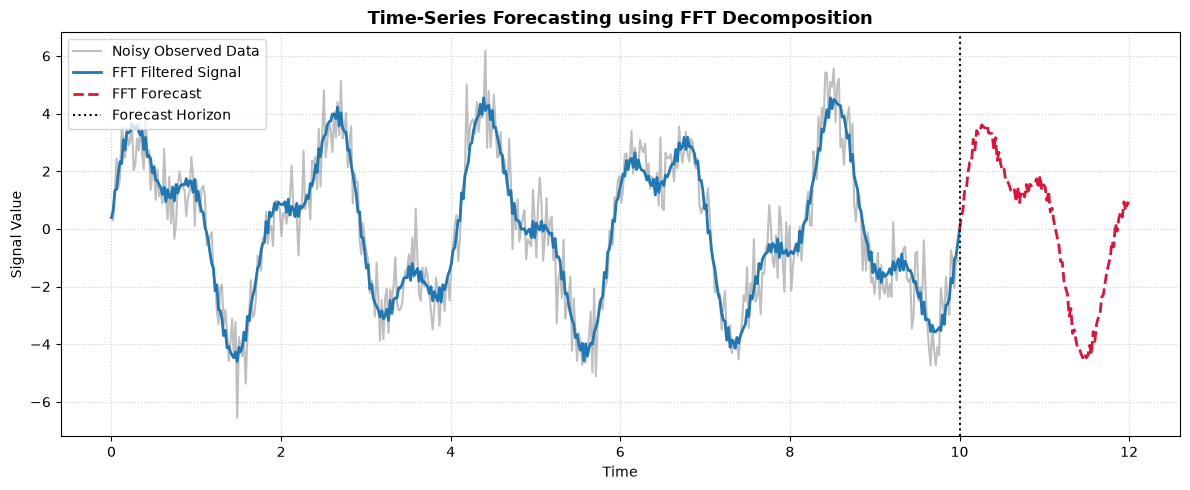

In [17]:
# 4. Visualization
plt.figure(figsize=(12, 5))
plt.plot(t, signal, color="gray", alpha=0.5, label="Noisy Observed Data")
plt.plot(t, reconstructed_signal, color="#1f77b4", lw=2, label="FFT Filtered Signal")
plt.plot(t_future, forecast, color="crimson", lw=2, linestyle="--", label="FFT Forecast")

plt.axvline(x=10, color="black", linestyle=":", lw=1.5, label="Forecast Horizon")
plt.title("Time-Series Forecasting using FFT Decomposition", fontsize=13, fontweight="bold")
plt.xlabel("Time")
plt.ylabel("Signal Value")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Real-Time Cloud-Based Labor Market Analysis & Trend Prediction

This notebook explores large-scale labor market analytics, leveraging cloud data warehouses and unstructured text processing (NLP) to extract skill sets, analyze labor supply/demand, and forecast career trends.

---

### Key Concepts & Architecture
* **Prototype-Driven Development:** Emphasizes moving quickly from data ingestion to a functional cloud-backed prototype (e.g., within a 3-day hackathon constraint) [00:12:14].
* **Massive Scale Ingestion:** Handling millions of unstructured records—such as curriculum vitae (CVs) and job vacancy advertisements—totaling gigabytes to terabytes of data [00:10:52].
* **Classification Standards:** Utilizing standardized European taxonomies like **ESCO** (European Skills, Competences, Qualifications, and Occupations) to map unstructured text into structured skill-occupation graphs [00:11:39].
* **Cloud Infrastructure:** Decoupling storage and computing by coupling big data query engines (like Google BigQuery) with interactive visualization frontends (like Tableau) [00:17:56].

---

### Core Analytical Modules

1. **Skill Supply vs. Demand Mapping:**
   * **Supply:** Extracted from candidate CVs showing active skills within specific regional or national economies (NUTS classification) [00:20:04].
   * **Demand:** Extracted from employer job postings to identify trending versus obsolete skills [00:14:52].
2. **Skill Gap Analysis:** Cross-referencing supply and demand metrics to identify mismatches and guide educational policymakers [00:16:06].
3. **Migration & Career Path Tracking:** Monitoring cross-border labor movement (e.g., tracking where professionals migrate for better opportunities) and building career recommendation engines [00:16:14, 00:24:26].

---

### Advantages vs. Limitations

* **Advantages:**
  * Real-time visibility into dynamic labor market shifts instead of relying on delayed census reports [00:16:57].
  * Empowers policymakers, academic institutions, and job seekers with data-driven career insights [00:09:58].
* **Limitations:**
  * Inherent biases in scraped job portals and CV databases [00:15:33].
  * Requires robust NLP pipelines to accurately parse messy, unstructured human text into standardized ontologies [00:11:39].

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Simulate labor market data for various technical skills
np.random.seed(42)
skills = [
    "Python & Machine Learning", "Cloud Architecture (BigQuery/AWS)", 
    "Traditional Accounting", "Legal Compliance", 
    "Data Visualization (Tableau/PowerBI)", "Legacy System Maintenance",
    "NLP & Text Mining", "SQL & Database Management"
]

n_skills = len(skills)
# Simulate supply (available workers) and demand (employer job postings) scores (0-100 scale)
demand_score = np.array([85, 90, 40, 50, 75, 30, 80, 88])
supply_score = np.array([60, 50, 70, 65, 70, 60, 45, 75])

labor_df = pd.DataFrame({
    "Skill": skills,
    "Demand": demand_score,
    "Supply": supply_score
})

# Calculate Skill Gap (Positive = Shortage/High Demand, Negative = Oversupply)
labor_df["Skill_Gap"] = labor_df["Demand"] - labor_df["Supply"]
labor_df = labor_df.sort_values(by="Skill_Gap", ascending=False)

print("--- Labor Market Skill Gap Analysis ---")
print(labor_df.to_string(index=False))

--- Labor Market Skill Gap Analysis ---
                               Skill  Demand  Supply  Skill_Gap
   Cloud Architecture (BigQuery/AWS)      90      50         40
                   NLP & Text Mining      80      45         35
           Python & Machine Learning      85      60         25
           SQL & Database Management      88      75         13
Data Visualization (Tableau/PowerBI)      75      70          5
                    Legal Compliance      50      65        -15
              Traditional Accounting      40      70        -30
           Legacy System Maintenance      30      60        -30


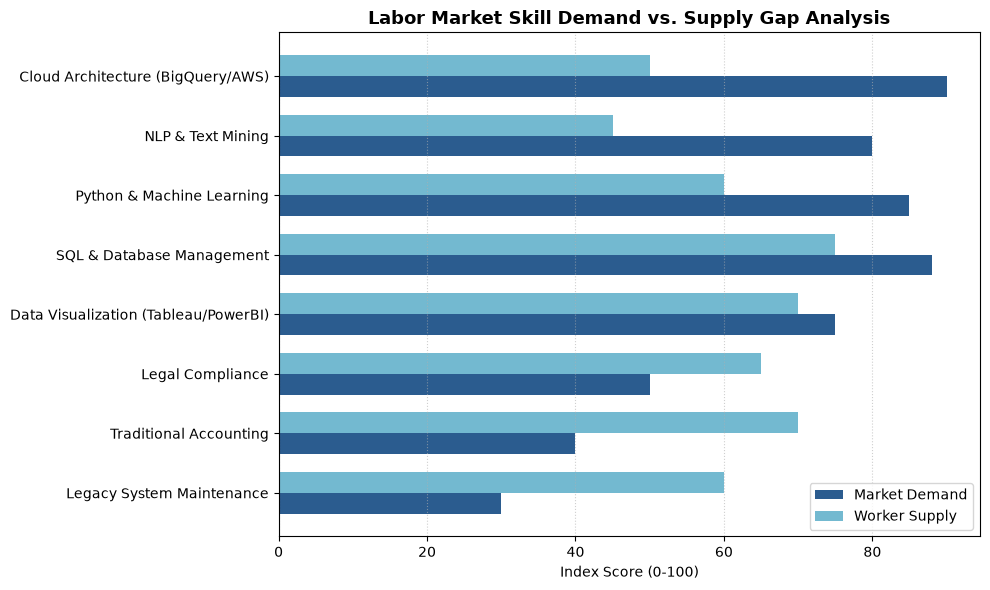

In [19]:
# 2. Visualization of Labor Market Gaps
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(labor_df))

plt.barh(x + bar_width / 2, labor_df["Demand"], bar_width, label="Market Demand", color="#2b5c8f")
plt.barh(x - bar_width / 2, labor_df["Supply"], bar_width, label="Worker Supply", color="#73b9d0")

plt.yticks(x, labor_df["Skill"])
plt.xlabel("Index Score (0-100)")
plt.title("Labor Market Skill Demand vs. Supply Gap Analysis", fontsize=13, fontweight="bold")
plt.grid(True, axis="x", linestyle=":", alpha=0.6)
plt.legend(loc="lower right")
plt.gca().invert_yaxis()  # Highest shortage at the top

plt.tight_layout()
plt.show()